In [32]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [33]:
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [34]:
def bmi_calc(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    
    state['bmi'] = round(bmi, 2)
    
    return state

In [35]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [36]:
#define your state
state = StateGraph(BMIState)

#define nodes
state.add_node('bmi_calc', bmi_calc)
state.add_node('label_bmi', label_bmi)

#define edges
state.add_edge(START, 'bmi_calc')
state.add_edge('bmi_calc', 'label_bmi')
state.add_edge('label_bmi', END)

#compile
workflow = state.compile()

In [37]:
initial_state = {'weight_kg': 74, 'height_m': 1.77}

final_workflow = workflow.invoke(initial_state)

print(final_workflow['category'])

Normal


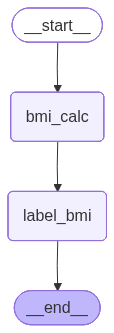

In [38]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())